# GDP Forecasting with ARIMA

This notebook forecasts GDP for selected countries using ARIMA models. Functions for data loading, plotting, and Excel output are included in a single cell.


In [ ]:
import warnings
# Suppress FutureWarnings globally
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', message=r".*force_all_finite.*")
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import pmdarima as pm
import pandas as pd
import numpy as np #numpy is installed but not used
import os
import time
from openpyxl import Workbook
from openpyxl.utils.dataframe import dataframe_to_rows
from openpyxl.styles import PatternFill, Alignment, Font, Border, Side
import openpyxl


In [ ]:
# J61 added here

OECD_PATH = '../Data/' # windows style: r".\\"

def clean_world_bank_data(rough):
    
    # a. data description:
    col = 0
    col_name = rough.columns[col] #column to search in
    mask = rough.iloc[:, col].apply(lambda x: isinstance(x, str) and x.lower().startswith("data from database"))

    idx = mask[mask].index[col]  # first matching row index

    file_description = [rough.at[idx, col_name], rough.at[idx + 1, col_name] if idx + 1 in rough.index else None]

    # replace both with NaN
    rough.at[idx, col_name] = np.nan
    if idx + 1 in rough.index:
        rough.at[idx + 1, col_name] = np.nan

    # b. remove NaN rows from the bottom
    rough.dropna(how='all', inplace=True)

    # c. remove constant columns while saving the entries in file_description
    for col in rough.columns:
        unique_vals = rough[col].unique()
        if len(unique_vals) == 1:
            file_description.append(unique_vals[0])
            rough = rough.drop(columns=[col])

    rough.Time = rough.Time.astype("Int16")

    rough.drop(columns=["Time Code"], inplace=True)

    # Replace column names with the letters inside brackets
    rough.columns = [col.split('[')[-1].split(']')[0] if '[' in col and ']' in col else col for col in rough.columns]

    return rough, file_description

def data_upload_WorldBank(filename, year, country, WorldBank_table_type='GDP', currency_exchange_type='PA_NUS_USD'):

    start_time = time.time()
    print("working directory of func_data_upload_OECD_salaries3.py is: ",os.getcwd())  # Print the current working directory

    # 1. Loading OECD data
    rough = pd.read_csv(filename)

    # Remove imports from matrix
    OECD_rough = OECD_rough.set_index(OECD_rough.columns[0])  # Set first column as index
    OECD_rough.index = OECD_rough.index.astype(str)  # Ensure index is strings
    OECD = OECD_rough[~OECD_rough.index.str.startswith("IMP_")]
    simple_II_labels = OECD_rough.columns.tolist()[OECD_rough.columns.get_loc("A01_02") : OECD_rough.columns.get_loc("T") + 1]
    #In OECD there's no description of the labels (codes) in owrds. I should refer to Mira's file for that. try Input_Codes_Map.xlsx
    OECD.index = OECD.index.str.removeprefix(table_type + '_')
    # probably delete the following chunk:
    II = OECD.loc[simple_II_labels, simple_II_labels]
    household_expenditure = OECD.loc[simple_II_labels, 'HFCE']
    final_demand_columns = ['HFCE',	'NPISH',	'GGFC',	'GFCF',	'INVNT',	'DPABR',	'CONS_NONRES',	'EXPO',	'IMPO']
    other_final_demand = OECD.loc[simple_II_labels, final_demand_columns[1:]] #exluding HFCE - household expenditure
    GDP         = OECD.loc['VALU', simple_II_labels]
    output      = OECD.loc['OUTPUT', simple_II_labels]
    #I don't need to worry bout household_expenditure of GDP or output - they are both 0
    # but output of GDP is given and should be marked independently


    # 4. Upload salaries from a different file of OECD UTF-8SUT 

    # WSL-compatible path
    #old file, only Canada: additional_filepath = "/mnt/c/NavitComputer24/2024_NES/Economics/Data/OECDsalaries/UTF-8SUT Use, Value added and its components by activity.csv"
    # link for additional OECD https://data-explorer.oecd.org/vis?df[ds]=dsDisseminateFinalDMZ&df[id]=DSD_NASU%40DF_USEVA_T1600&df[ag]=
    # OECD.SDD.NAD&df[vs]=1.0&hc[Transaction]=Output&pg=0&snb=53&tm=input-output&utm_source=chatgpt.com&dq=A.FRA%2BJPN%2BUSA%2BGBR%2BITA%2BDEU%2B
    # CAN.B2A3G%2BB2A3N%2BD11%2BD1%2BD29X39%2BB3G%2BB1G%2BP2%2BP1._T%2BA%2BB%2BC%2BD%2BE%2BF%2BG%2BH%2BI%2BJ%2BK%2BL%2BM%2BN%2BO%2BP%2BQ%2BR%2BS%2BT%2BU%2B_
    # X....V.&pd=2011%2C2022&to[TIME_PERIOD]=false&vw=tb
    additional_filepath = "/mnt/c/NavitComputer24/2024_NES/Economics/Data/OECDsalaries/additionalOECD.csv"
    additional_data_rough = pd.read_csv(additional_filepath)
    # Keep only columns where there is more than one unique value
    data2 = additional_data_rough.loc[:, additional_data_rough.nunique() > 1]
    data2 = data2[data2.REF_AREA == country] # keep only the rows for the country
    data2 = data2.rename(columns={"ACTIVITY": "detailed_sectors"})
    # to look at the titles of the detailed sectors
    data2_descriptions = data2[(data2["TIME_PERIOD"] ==int(year)) ] #.drop(columns=['Reference area','TIME_PERIOD','Transaction','OBS_VALUE','ACCOUNTING_ENTRY',
                                                                    #            'OBS_STATUS','Currency'])
    sector_description = dict(zip(data2_descriptions['detailed_sectors'], data2_descriptions['Economic activity']))

    #year = re.search(r'\d{4}', OECD_name).group() #this is a function and the year is an input variable

    # 4.2 putting data2 in OECD_additionaol_data
    # columns in data2: Transaction - GDP, salaries, taxes, etc.
    # detailed_sectors, Economic Activity - A, M, G, etc.
    # VALUATIONI, Valuation - Purchasers price, not applicable, basic price
    # TIME_PERIOD, OBS_VALUE = year and value
    # ACCOUNTING_ENTRY, Accounting entry - Expenditure, Balance (revenue minus expenditure), Revenue

    transaction_names = ['Value added, gross', 'Other taxes less other subsidies on production', 'Operating surplus and mixed income, net', 
                        'Wages and salaries', 'Compensation of employees']
    column_names = ['GDP', 'net_taxes_on_production', 'surplus_and_mixed_income_net', 
                    'salaries', 'employees_compensation' ]

    
    OECDadditional = pd.DataFrame()
    for ix, name in enumerate(transaction_names):     
        one_transaction_type= data2[(data2["TIME_PERIOD"] == int(year)) & (data2["Transaction"] == name)].drop(columns=["Economic activity","TIME_PERIOD","Transaction", 
                                                                                                                        "TRANSACTION",
                                                                                                                        'Reference area','TIME_PERIOD','Transaction','ACCOUNTING_ENTRY',
                                                                                                                        'OBS_STATUS','Currency'])
        # now GSPstatcan is with detailed OECD codes and we need to translate it to known OECD codes
        # from A01 and A02 to A01_02
        one_transaction_type['OECD_codes'] = one_transaction_type['detailed_sectors'].map(mapping_dict)
        one_transaction_type = one_transaction_type.sort_values(by="OECD_codes")

        # sum A01 and A02 to A01_02
        # Group by OECD_codes and sum the OBS_VALUE column
        one_transaction_type_grouped = one_transaction_type.groupby('OECD_codes', as_index=False)['OBS_VALUE'].sum()
        # GDPstatcan_grouped has OECD sectors but also other sectors. it has 95 rows. but the OECD sectors are correct (summed correctly)
        # I checked.
        
        # convert CAD to USD by PPP_or_exch
        one_transaction_type_grouped['OBS_VALUE_USD'] = (one_transaction_type_grouped['OBS_VALUE'] / PPP_or_exch).round(1)
        one_transaction_type_grouped.drop(columns=['OBS_VALUE'], inplace=True)
        
        # last step:
        # choose from it only codes that appear in OECD:
        if 'J' not in simple_II_labels:
            simple_II_labels_plus_J = simple_II_labels + ['J']
        df = one_transaction_type_grouped.set_index('OECD_codes').reindex(simple_II_labels_plus_J, fill_value=0).copy()   

        # Add to statcan_data under the corresponding column name
        OECDadditional[column_names[ix]] = df['OBS_VALUE_USD']

    # from J to a correct value of J61
    if "j61" not in OECDadditional.index:
        OECDadditional.loc["J61"] = OECDadditional.loc["J"] - OECDadditional.loc["J58T60"] - OECDadditional.loc["J62_63"]   
    OECDadditional = OECDadditional.drop("J")

    return PPP_or_exch, OECD, simple_II_labels, OECDadditional, sector_description

In [16]:



def get_worldbank_gdp_data(GDP_filename, plot_flag):

    rough = pd.read_csv(GDP_filename)
    print(f"Successfully loaded data with shape: {rough.shape}")
        
    worldbank_gdp_data, file_description = clean_world_bank_data(rough)

    print("\n dataframe data:\n")
    print(worldbank_gdp_data.head())

    # Plotting
    if plot_flag:
        countries = data.columns[1:]  # all country columns
        plt.figure(figsize=(10, 6))

        for country in countries:
            plt.plot(data['Time'], data[country], marker = 'o',label=country)
            plt.text(data['Time'].iloc[-1], data[country].iloc[-1], country, 
                    fontsize=9, verticalalignment='center')

        plt.xlabel('Year')
        plt.ylabel(file_description[2])  
        plt.title('file_description[2] of countries')
        plt.grid(True)
        plt.legend()  
        plt.show()

        # Trending
        max_data_years = data.Time.max()
        past_years = 10


    return worldbank_gdp_data


def plot_gdp_forecast(worldbank_gdp_data, forecast_gdp, countries, title):
    
    plt.figure(figsize=(12, 6))

    for country in countries:
        # Plot historical data and get the color assigned
        line_actual, = plt.plot(worldbank_gdp_data.index, worldbank_gdp_data[country], label=f"{country} actual")
        color = line_actual.get_color()
        
        # Plot forecasted data with the same color
        plt.plot(forecast_gdp.index, forecast_gdp[country], linestyle='--', color=color, label=f"{country} forecast")

    plt.xlabel("Year")
    plt.ylabel("GDP (current USD)")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


###############################################  printing to Excel  #####################################################

def create_excel_file_with_title(year: str, filename: str = "output.xlsx") -> int:
    wb = Workbook()
    ws = wb.active
    ws.title = year

    # Styles
    green = PatternFill(start_color="00C000", end_color="00C000", fill_type="solid")
    bold_font = Font(bold=True)
    center_align = Alignment(horizontal="center", vertical="center")
    black_border = Border(
        left=Side(style='thin', color='000000'),
        right=Side(style='thin', color='000000'),
        top=Side(style='thin', color='000000'),
        bottom=Side(style='thin', color='000000')
    )

    # Merge title box over first 4 columns and 3 rows
    ws.merge_cells(start_row=1, start_column=1, end_row=3, end_column=4)
    cell = ws.cell(row=1, column=1)
    cell.value = f"EIA details - {year}"
    cell.fill = green
    cell.font = bold_font
    cell.alignment = center_align
    cell.border = black_border

    wb.save(filename)

    return 1  # Next available column after title box

def append_styled_matrix_to_excel(df, matrix_name, year: str, start_col: int, filename: str = "output.xlsx", title_size=3) -> int:
    # Infer matrix name from variable name if not provided
    if matrix_name is None:
        frame = inspect.currentframe().f_back
        matrix_name = next((name for name, val in frame.f_locals.items() if val is df), "UnnamedMatrix")

    wb = openpyxl.load_workbook(filename)
    if year not in wb.sheetnames:
        raise ValueError(f"Sheet named '{year}' does not exist. Create it first using create_excel_file_with_title.")
    ws = wb[year]

    # Styles
    light_blue = PatternFill(start_color="ADD8E6", end_color="ADD8E6", fill_type="solid")
    green = PatternFill(start_color="00C000", end_color="00C000", fill_type="solid")
    bold_font = Font(bold=True)
    center_align = Alignment(horizontal="center", vertical="center")
    black_border = Border(
        left=Side(style='thin', color='000000'),
        right=Side(style='thin', color='000000'),
        top=Side(style='thin', color='000000'),
        bottom=Side(style='thin', color='000000')
    )

    # Convert DataFrame to rows (including index and header)
    rows = list(dataframe_to_rows(df, index=True, header=True))
    n_rows = len(rows)
    n_cols = len(rows[0])  # includes index

    # Green title merged over up to 4 columns
    merge_end_col = min(start_col + title_size, start_col + n_cols - 1)
    if merge_end_col > start_col:
        ws.merge_cells(start_row=4, start_column=start_col, end_row=4, end_column=merge_end_col)
    title_cell = ws.cell(row=4, column=start_col)
    title_cell.value = matrix_name
    title_cell.fill = green
    title_cell.font = bold_font
    title_cell.alignment = center_align

    # Write the matrix below the title
    for r_idx, row in enumerate(rows, start=5):
        for c_idx, val in enumerate(row):
            col = start_col + c_idx
            cell = ws.cell(row=r_idx, column=col, value=val)
            if r_idx == 5 or c_idx == 0:  # header or index
                cell.fill = light_blue
                cell.font = bold_font
            cell.border = black_border
            cell.alignment = center_align

    # Add a black separator column
    sep_col = start_col + n_cols
    for r in range(4, 5 + n_rows):
        cell = ws.cell(row=r, column=sep_col)
        cell.border = black_border
        cell.alignment = center_align

    wb.save(filename)

    return sep_col + 1  # Return column to start the next matrix (skip separator too)

def append_styled_series_to_excel(series: pd.Series, series_name, year: str, start_col: int, filename: str = "output.xlsx") -> int:
    # Infer series name from variable name if not provided
    if series_name is None:
        frame = inspect.currentframe().f_back
        series_name = next((name for name, val in frame.f_locals.items() if val is series), "UnnamedSeries")

    wb = openpyxl.load_workbook(filename)
    if year not in wb.sheetnames:
        raise ValueError(f"Sheet named '{year}' does not exist. Create it first using create_excel_file_with_title.")
    ws = wb[year]

    # Convert Series to DataFrame for uniformity
    df = series.to_frame(name=series.name if series.name else "Value")
    rows = list(dataframe_to_rows(df, index=True, header=True))
    n_rows = len(rows)
    n_cols = len(rows[0])  # Should be 2: index and value

    # Styles
    light_blue = PatternFill(start_color="ADD8E6", end_color="ADD8E6", fill_type="solid")
    green = PatternFill(start_color="00C000", end_color="00C000", fill_type="solid")
    bold_font = Font(bold=True)
    center_align = Alignment(horizontal="center", vertical="center")
    black_border = Border(
        left=Side(style='thin', color='000000'),
        right=Side(style='thin', color='000000'),
        top=Side(style='thin', color='000000'),
        bottom=Side(style='thin', color='000000')
    )

    # Green title merged over up to 2 columns
    merge_end_col = min(start_col + 1, start_col + n_cols - 1)
    if merge_end_col > start_col:
        ws.merge_cells(start_row=4, start_column=start_col, end_row=4, end_column=merge_end_col)
    title_cell = ws.cell(row=4, column=start_col)
    title_cell.value = series_name
    title_cell.fill = green
    title_cell.font = bold_font
    title_cell.alignment = center_align

    # Write the series below the title
    for r_idx, row in enumerate(rows, start=5):
        for c_idx, val in enumerate(row):
            col = start_col + c_idx
            cell = ws.cell(row=r_idx, column=col, value=val)
            if r_idx == 5 or c_idx == 0:  # header or index
                cell.fill = light_blue
                cell.font = bold_font
            cell.border = black_border
            cell.alignment = center_align

    # Add a black separator column
    sep_col = start_col + n_cols
    for r in range(4, 5 + n_rows):
        cell = ws.cell(row=r, column=sep_col)
        cell.border = black_border
        cell.alignment = center_align

    wb.save(filename)
    return sep_col + 1





## Load GDP Data

We first load the World Bank GDP data for the selected countries, rename the year column, and set it as the index.


In [17]:
# 01 upload gdp data

GDP_filename ='WorldBank_GDP.csv'
worldbank_gdp_data = get_worldbank_gdp_data(GDP_filename, False)
worldbank_gdp_data.rename(columns={'Time': 'year'}, inplace=True)
worldbank_gdp_data['year'] = worldbank_gdp_data['year'].astype(int)
worldbank_gdp_data.set_index('year', inplace=True)


Successfully loaded data with shape: (55, 11)

 dataframe data:

   Time           ITA           JPN           CAN           FRA           DEU  \
0  1975  2.282210e+11  5.328610e+11  1.744200e+11  3.567810e+11  4.924340e+11   
1  1976  2.252350e+11  5.988840e+11  2.072720e+11  3.684880e+11  5.216590e+11   
2  1977  2.581900e+11  7.370690e+11  2.123250e+11  4.067360e+11  6.026980e+11   
3  1978  3.157840e+11  1.035610e+12  2.193700e+11  5.017240e+11  7.431830e+11   
4  1979  3.945850e+11  1.077910e+12  2.438910e+11  6.082190e+11  8.845740e+11   

            GBR           USA  
0  2.417570e+11  1.684900e+12  
1  2.326150e+11  1.873410e+12  
2  2.630660e+11  2.081830e+12  
3  3.358830e+11  2.351600e+12  
4  4.389940e+11  2.627330e+12  


## Train-Test Split

We split the data into training and test sets, using 80% for training and 20% for testing.


In [18]:
train_test_split = 0.8
train_size = int(len(worldbank_gdp_data) * train_test_split)
train, test = worldbank_gdp_data[:train_size], worldbank_gdp_data[train_size:]


In [19]:
forecast_horizon = 16  # years ahead to predict
forecast_years = list(range(worldbank_gdp_data.index.max() + 1,
                            worldbank_gdp_data.index.max() + forecast_horizon + 1))
countries = ['ITA','JPN','CAN','FRA','DEU','GBR','USA']
forecast_gdp = pd.DataFrame(index=pd.Index(forecast_years, dtype=int), columns=countries)
    

## Fit ARIMA and Forecast

For each country, we select the best ARIMA(p,d,q) model using `auto_arima`, forecast the test set to evaluate accuracy, refit on the full series, and forecast 16 years ahead. The selected ARIMA orders are stored for reference.


In [20]:
arima_orders = {}
for country in countries:
    print(f"\nProcessing {country}...")
    
    # Extract series
    train_series = worldbank_gdp_data[:train_size][country]
    test_series = worldbank_gdp_data[train_size:][country]
    
    # Fit ARIMA model (fixed d)
    d_value = 2  # or set to None for automatic selection
    model = pm.auto_arima(
        train_series,
        start_p=0, max_p=5,
        start_q=0, max_q=5,
        d=d_value,
        seasonal=False,
        stepwise=False,
        suppress_warnings=True,
        error_action='ignore',
        information_criterion='aic',
        n_jobs=-1
    )
    
    print(f"Selected ARIMA order for {country}: {model.order}")
    
    # Forecast on test
    prediction_on_test = model.predict(n_periods=len(test_series))
    mse = mean_squared_error(test_series, prediction_on_test)
    print(f"Test MSE for {country}: {mse:.2e}")
    
    # Refit on full series
    model.fit(worldbank_gdp_data[country])
    arima_orders[country] = model.order
    
    # Forecast 16 years ahead
    forecast_values = model.predict(n_periods=forecast_horizon)
    forecast_values.index = forecast_years
    forecast_gdp[country] = forecast_values



Processing ITA...


/home/orih/miniconda3/envs/EIA_ML_env13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/orih/miniconda3/envs/EIA_ML_env13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/orih/miniconda3/envs/EIA_ML_env13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/orih/miniconda3/envs/EIA_ML_env13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/orih/miniconda3/envs/EIA_ML_env13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: F

Selected ARIMA order for ITA: (0, 2, 1)
Test MSE for ITA: 4.63e+22

Processing JPN...


/home/orih/miniconda3/envs/EIA_ML_env13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/orih/miniconda3/envs/EIA_ML_env13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/orih/miniconda3/envs/EIA_ML_env13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/orih/miniconda3/envs/EIA_ML_env13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/orih/miniconda3/envs/EIA_ML_env13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: F

Selected ARIMA order for JPN: (2, 2, 3)
Test MSE for JPN: 8.81e+23

Processing CAN...


...

Selected ARIMA order for DEU: (0, 2, 1)
Test MSE for DEU: 5.60e+23

Processing GBR...


/home/orih/miniconda3/envs/EIA_ML_env13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/orih/miniconda3/envs/EIA_ML_env13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/orih/miniconda3/envs/EIA_ML_env13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/orih/miniconda3/envs/EIA_ML_env13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/orih/miniconda3/envs/EIA_ML_env13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: F

Selected ARIMA order for GBR: (3, 2, 2)
Test MSE for GBR: 4.81e+23

Processing USA...


/home/orih/miniconda3/envs/EIA_ML_env13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/orih/miniconda3/envs/EIA_ML_env13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/orih/miniconda3/envs/EIA_ML_env13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/orih/miniconda3/envs/EIA_ML_env13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/orih/miniconda3/envs/EIA_ML_env13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: F

Selected ARIMA order for USA: (0, 2, 0)
Test MSE for USA: 2.66e+24


## Plot and Output

Plot the forecast and optionally save the results to Excel. This cell does not require explanation.


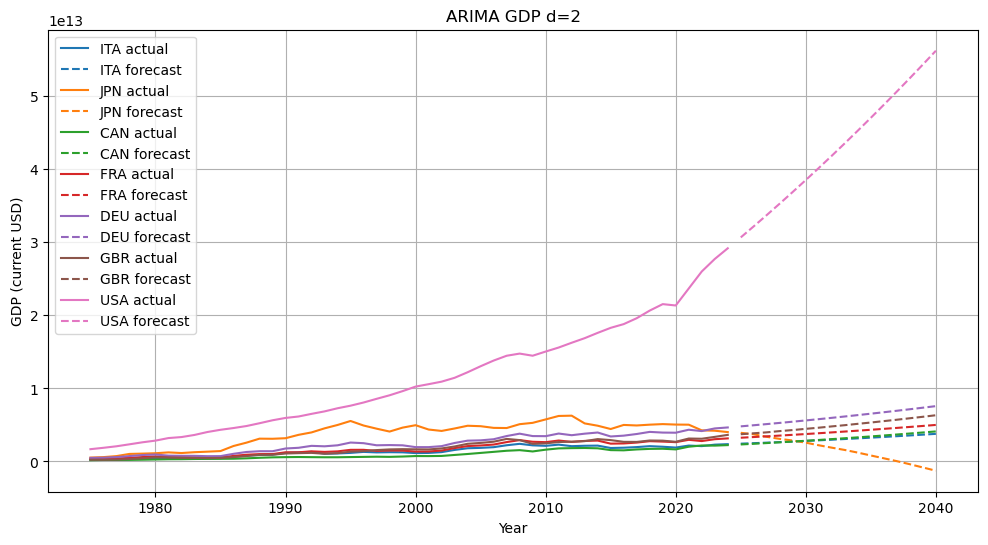


Selected ARIMA orders for all countries:
ITA: ARIMA(0, 2, 1)
JPN: ARIMA(2, 2, 3)
CAN: ARIMA(0, 2, 1)
FRA: ARIMA(0, 2, 1)
DEU: ARIMA(0, 2, 1)
GBR: ARIMA(3, 2, 2)
USA: ARIMA(0, 2, 0)


In [21]:
plot_gdp_forecast(worldbank_gdp_data, forecast_gdp, countries, title=f"ARIMA GDP d={d_value}")

print("\nSelected ARIMA orders for all countries:")
for country, order in arima_orders.items():
    print(f"{country}: ARIMA{order}")

# Optional: save to Excel
if 0:
    gdp = pd.concat([worldbank_gdp_data, forecast_gdp])
    gdp.to_csv("Bench_predictions/gdp_ARIMAgdp_currentUSD04.csv", index=True)
